In [2]:
print("test")

test


In [3]:
#Charger dataset
from datasets import load_dataset
import numpy as np

c:\S8\AI\Sentiment Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
ds = load_dataset("imdb") #the datasets library recognizes "imdb" as a predefined dataset.

In [5]:
ds
#Le dataset est composé de 3 parties : train et test, que nous utiliserons, et unsupervised que nous n’utiliserons pas.
#Chaque partie contient des exemples de critiques de films avec leur sentiment associé (positif ou négatif).

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [6]:
train_df = ds['train'].to_pandas()
#to_pandas() pour convertir en Pandas DataFrame :
# facile à afficher, filtrer, analyser
# compatible avec beaucoup de libs (matplotlib, sklearn, etc.)

In [7]:
# train_df.head()
train_df.sample(5)

,text,label
5336,"I have no idea why they made this version of ""...",0
5187,...that seem to be fooling people into seeing ...,0
14708,I've just finished listening to the director's...,1
8085,A friend and I went through a phase some (alot...,0
23047,I have a feeling that the Warners Bros Depress...,1


In [8]:
#vérifier si le dataset est équilibré:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [9]:
# train_df['sentiment'] = train_df['label'].map({0: 'negatif', 1: 'positif'})
train_df['sentiment'] = np.where(train_df['label']==1, "positif","negatif")

In [10]:
train_df
#train_df['sentiment'] same as train_df.sentiment

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negatif
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negatif
2,If only to avoid making this type of film in t...,0,negatif
3,This film was probably inspired by Godard's Ma...,0,negatif
4,"Oh, brother...after hearing about this ridicul...",0,negatif
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positif
24996,I love this movie like no other. Another time ...,1,positif
24997,This film and it's sequel Barry Mckenzie holds...,1,positif
24998,'The Adventures Of Barry McKenzie' started lif...,1,positif


In [11]:
train_df.sentiment.value_counts()

sentiment
negatif    12500
positif    12500
Name: count, dtype: int64

<Axes: >

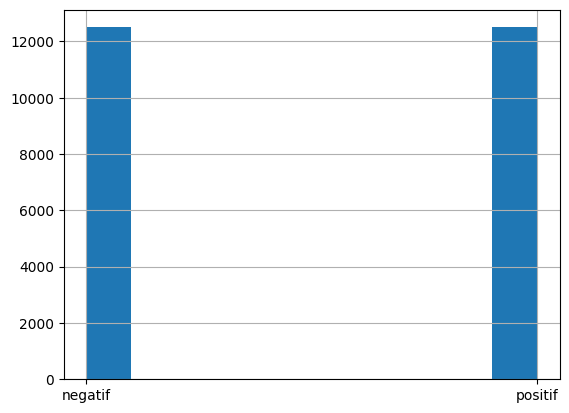

In [12]:
train_df.sentiment.hist()

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
    #0.2 cad 20% examples rest gold_examples
)

In [15]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [16]:
columns = ["text", "sentiment"]
gold_examples = (
                 gold_examples_df[columns]
                 .sample(20, random_state=34)
                 .to_json(orient="records")#Très pratique pour envoyer à un LLM/API.
                ) 

In [17]:
import json

In [18]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positif'}

## Elaborer les prompts

#### Prompt 1: Zero-shot

In [19]:
user_prompt_template = """```{movie_review}```"""

In [20]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positif' or 'negatif'
Do not explain your answer.
""" 

In [21]:
zero_shot_prompt = [
    {"role":"system", "content": zero_shot_system_message}
]

In [22]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
""" 

In [23]:
#pour le few shot prompt nous aurons besoin de quelques exemples variés, cad des critiques positives et négatives
#on va diviser les examples on deux (positif et negatif) et prendre 4 exemples de chaque pour les inclure in random order dans le prompt few shot
examples_df.shape

(20000, 3)

In [24]:
positif_reviews_df = (
        examples_df[examples_df.sentiment=="positif"][columns]
        .sample(4)
)

In [25]:
negatif_reviews_df = (
                examples_df[examples_df.sentiment=="negatif"][columns]
                .sample(4))

In [26]:
negatif_reviews_df

,text,sentiment
7691,"Wow, not only is this film a ""new lesson in re...",negatif
972,"As someone who lived through,and still remembe...",negatif
5982,What exactly was going on during World War 11 ...,negatif
9642,"I dont know about you, but I've always felt dr...",negatif


In [27]:
positif_reviews_df.shape, negatif_reviews_df.shape

((4, 2), (4, 2))

In [28]:
import pandas as pd

In [29]:
ex = pd.concat([positif_reviews_df, negatif_reviews_df])

In [30]:
ex
#problème : les exemples positifs sont regroupés et les négatifs aussi, il faut les mélanger

,text,sentiment
15429,The extraordinary Rosemary Forsyth is the main...,positif
16676,"No, I'm not joking around. If you ever, EVER, ...",positif
21743,"Walter Pidgeon is Braley Mason, a civil attorn...",positif
23387,"If you came into the film with expectations, t...",positif
7691,"Wow, not only is this film a ""new lesson in re...",negatif
972,"As someone who lived through,and still remembe...",negatif
5982,What exactly was going on during World War 11 ...,negatif
9642,"I dont know about you, but I've always felt dr...",negatif


In [31]:
examples = examples_df.sample(4*2, replace=False).to_json(orient='records')

In [32]:
json.loads(examples)

[{'text': "So this is what actress Kim Basinger has succumbed to? Mmm\x85 to tell the truth the film's title is something quite eye grabbing to getting your interest and plot outline reads so basic, but simplicity can have its strengths. Anyhow by the end of 'While She Was Out' I was left feeling rather indifferent. Not the worse (despite being engulfed by negatives), but there's easily way better in what is an causally lukewarm, but compact and unbalanced late-night survival fable of a feeble suburban housewife stranded in the woods trying to fight for her life after she witnessed the death of a rent a cop that came to her aid, when she provoked an ugly exchange with some punks in a shopping car park.<br /><br />The problem here falls on the misguidedly erratic and foreseeable material (taken from a short story), along with the very variable performances. The flimsy script was poorly thought-out (which isn't so good when your plot has a slight structure to hang off), so many wretched 

In [33]:
def create_examples(dataset, n=4):
    positive_reviews_df = (
                dataset[dataset['sentiment'] == 'positif'][columns]
                .sample(n)
                )
    negative_reviews_df = (
                dataset[dataset['sentiment'] == 'negatif'][columns]
                .sample(n)
                )

    examples_df = pd.concat([positive_reviews_df, negative_reviews_df])
    examples = examples_df.sample(2*n, replace=False)
    
    return examples.to_json(orient='records')

In [34]:
examples_df.shape

(20000, 3)

In [35]:
few_shot_examples = create_examples(examples_df, n=1)

In [36]:
json.loads(few_shot_examples)

[{'text': "Some bad reviews here for this and I understand why but treat it as a low budget serial killer film and you might get more from it than most.<br /><br />I thought that this worked in a way because afterwards I felt dirty and wanted to take a long shower so that is some degree of success isn't it?<br /><br />I would say there is just the right level of sleaze here to get under your skin although the acting is maybe a bit too uneven. David Hess is only in this brielfy so don not get your hopes up to much if you like Last House.<br /><br />Other than that - worth a look.",
  'sentiment': 'positif'},
 {'text': 'Mark Hamill should have felt mighty embarrassed with CORVETTE SUMMER! This time, he uses a new kind of "force" to regain the possession of his dream machine, a bright red \'Vette. It looks like another sour teen-age flick the first half-hour and does a U-turn in heading for the wrong direction. The writing and directing jobs are dreadfully done, with a few scenes you can\

In [37]:
#few shot propt fct:
def create_few_shot_prompt(system_message, examples, user_prompt_template):
    few_shot_prompt = [
        {"role": "system", "content": system_message},
    ]

    for example in json.loads(examples) : 
        review = example["text"]
        sentiment = example["sentiment"]
        few_shot_prompt.append({"role": "user", "content": user_prompt_template.format(movie_review=review)})
        few_shot_prompt.append({"role": "assistant", "content": f"{sentiment}"}) 
        #la format f"{}" c'est juste pour spécifier que c est du text

    return few_shot_prompt

In [38]:
few_shot_prompt = create_few_shot_prompt(few_shot_system_message, few_shot_examples, user_prompt_template)

In [39]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': "```Some bad reviews here for this and I understand why but treat it as a low budget serial killer film and you might get more from it than most.<br /><br />I thought that this worked in a way because afterwards I felt dirty and wanted to take a long shower so that is some degree of success isn't it?<br /><br />I would say there is just the right level of sleaze here to get under your skin although the acting is maybe a bit too uneven. David Hess is only in this brielfy so don not get your hopes up to much if you like Last House.<br /><br />Other than that - worth a look.```"},
 {'role': 'assistant', 'content': 'positif'},
 {'role': 'user',
  'content': '```Mark Hamill should have felt migh

## Chain of thought

In [40]:
#cot: chain of thought prompting, c'est une technique qui consiste à demander au modèle de raisonner étape par étape pour arriver à la réponse finale(instructions a suivre)
cot_few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.

Instructions:
1.Carefully read the text of the review and think through the options for sentiment provided. 
2.Consider the overall sentiment of the review and estimate the probability of the review being positive or negative

To reiterate, your answer should strictly only contain the labels: positif or negatif.
"""

In [41]:
cot_few_shot_prompt = create_few_shot_prompt(
                        cot_few_shot_system_message, 
                        few_shot_examples, 
                        user_prompt_template
                        )

In [42]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n\nInstructions:\n1.Carefully read the text of the review and think through the options for sentiment provided. \n2.Consider the overall sentiment of the review and estimate the probability of the review being positive or negative\n\nTo reiterate, your answer should strictly only contain the labels: positif or negatif.\n"},
 {'role': 'user',
  'content': "```Some bad reviews here for this and I understand why but treat it as a low budget serial killer film and you might get more from it than most.<br /><br />I thought that this worked in a way because afterwards I felt dirty and wanted to take a long shower so that is some degree of success isn't it?<br /><br />I would say there is just the right level of sleaze here to get u

## Evaluation des trois prompts avec ollama

In [43]:
from sklearn.metrics import f1_score

In [44]:
#fct d'évalutions des prompt:
def evaluate_prompt(prompt, gold_examples, user_prompt_template, llm='llama3.2'):
    predicted_sentiments = []
    ground_truth_sentiments=[]

    for example in json.loads(gold_examples) : 
        review = example["text"]
        sentiment = example["sentiment"]
        user_input = {"role":"user", "content": user_prompt_template.format(movie_review=review)} 

        try:
            resp = llm.invoke(prompt + [user_input])
            if 'negatif' in resp.content.strip().lower():
                predicted = 'negatif'

            elif 'positif' in resp.content.strip().lower():
                predicted = 'positif'

            else:
                predicted = 'unknown'

            predicted_sentiments.append(predicted)
            ground_truth_sentiments.append(sentiment)

            print(predicted, sentiment)

        except Exception as e:
            print(f"Error processing review: {e}")
            predicted = 'error'
            continue
    return f1_score(ground_truth_sentiments, predicted_sentiments, average='micro')


In [45]:
#Pour évaluer un prompt il faut d'abord définir les mesures d'évaluation, 
#Les plus courantes sont la précision, le rappel et le F1-score, accuracy(trop simple). 

#on utilisera:
#score micro-F1 = 2 * (precision * recall) / (precision + recall)


In [46]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.2", temperature=0)
#run the command in cmd: ollama run llama3.2

In [ ]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template, llm)

positif positif
negatif negatif
negatif positif
positif positif
positif positif
positif positif
negatif negatif
negatif negatif
negatif negatif


In [ ]:
evaluate_prompt(few_shot_prompt, gold_examples, user_prompt_template, llm)

positif positif
negatif negatif
positif positif
positif positif
positif positif
positif positif
negatif negatif
negatif negatif
negatif negatif
positif positif
positif positif
negatif negatif
negatif negatif
negatif positif
positif positif
positif positif
negatif negatif
negatif positif
positif positif
negatif negatif


0.9

In [ ]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_prompt_template, llm)
